<div style="display:flex; justify-content:space-between; align-items:center; width:100%; margin:8px 0 24px 0;">
  <div style="text-align:left;">
    <img src="https://www.ec-nantes.fr/medias/photo/logocn-rvb_1648479844750-png?ID_FICHE=178994&amp;INLINE=FALSE" alt="Centrale Nantes" style="height:72px; width:auto;">
  </div>
  <div style="text-align:right; font-size:18px; font-weight:600; color:#17324d; line-height:1.35;">
    MSc. CORO DASSIP
  </div>
</div>

<div style="border:2px solid #333; padding:14px 20px; margin:15px auto 25px auto; width:85%; max-width:900px; box-sizing:border-box; text-align:center;">
  <h1 style="margin:0;"><b>Filtering in Spatial Domain — Implementation</b></h1>
</div>

## Setup — Environment and Configuration


In [81]:

from pathlib import Path
import math

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
import cv2

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 11

## 1. Data and Output Paths


In [82]:

def locate_lab_root(start: Path) -> Path:
    """Locate lab root."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the lab root containing data/ and notebooks/."
    )
LAB_DIR = locate_lab_root(Path.cwd())
DATA_DIR = LAB_DIR / "data"
OUTPUT_DIR = LAB_DIR / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
DATA_FILES = sorted(
    path for path in DATA_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)

assert DATA_FILES, f"No supported images found in: {DATA_DIR}"
def select_input_image(*tokens: str) -> Path:
    """Select input image."""
    tokens = tuple(token.lower() for token in tokens)
    matches = [
        path for path in DATA_FILES
        if all(
            token in path.relative_to(DATA_DIR).as_posix().lower()
            for token in tokens
        )
    ]
    if not matches:
        raise FileNotFoundError(
            f"No image matching {tokens} found in {DATA_DIR}"
        )
    return matches[0]
ROLE_PATTERNS = {
    "moon": ("moon-blurred",),
    "ascent": ("ascentb",),
    "einstein_ref": ("einstein/ref",),
    "einstein_gaussian": ("einstein_gaussian",),
    "einstein_salt": ("saltandpepper",),
    "einstein_speckle": ("speckle",),
    "taj_ref": ("tajmahal/ref",),
    "zebra_ref": ("zebra/ref",),
    "monarch_ref": ("monarch/ref",),
}

INPUT_IMAGES = {
    role: select_input_image(*patterns)
    for role, patterns in ROLE_PATTERNS.items()
}

print("Lab directory :", LAB_DIR)
print("Data directory:", DATA_DIR)
print("Images discovered:", len(DATA_FILES))
print("Experiment roles :", len(INPUT_IMAGES))
print("Output folder :", OUTPUT_DIR)

Lab directory : /home/denos/Master_SIP_EC-Nantes/labs/image-processing/filtering-in-spatial-domain
Data directory: /home/denos/Master_SIP_EC-Nantes/labs/image-processing/filtering-in-spatial-domain/data
Images discovered: 27
Experiment roles : 9
Output folder : /home/denos/Master_SIP_EC-Nantes/labs/image-processing/filtering-in-spatial-domain/outputs/figures


### Data Inventory


In [83]:

def load_grayscale_image(path: Path) -> np.ndarray:
    """Load grayscale image."""
    return np.array(Image.open(path).convert("L"), dtype=np.uint8)
def load_rgb_image(path: Path) -> np.ndarray:
    """Load RGB image."""
    return np.array(Image.open(path).convert("RGB"), dtype=np.uint8)
einstein_reference_image = load_grayscale_image(INPUT_IMAGES["einstein_ref"])
einstein_gaussian_noise_image = load_grayscale_image(INPUT_IMAGES["einstein_gaussian"])
einstein_salt_pepper_noise_image = load_grayscale_image(INPUT_IMAGES["einstein_salt"])
einstein_speckle_noise_image = load_grayscale_image(INPUT_IMAGES["einstein_speckle"])

moon = load_grayscale_image(INPUT_IMAGES["moon"])
ascent = load_grayscale_image(INPUT_IMAGES["ascent"])

taj_reference_image = load_rgb_image(INPUT_IMAGES["taj_ref"])
zebra_reference_image = load_rgb_image(INPUT_IMAGES["zebra_ref"])
monarch_reference_image = load_rgb_image(INPUT_IMAGES["monarch_ref"])

for name, image in {
    "einstein_ref": einstein_reference_image,
    "einstein_gaussian": einstein_gaussian_noise_image,
    "einstein_salt": einstein_salt_pepper_noise_image,
    "einstein_speckle": einstein_speckle_noise_image,
    "moon": moon,
    "ascent": ascent,
    "taj_ref": taj_reference_image,
    "zebra_ref": zebra_reference_image,
    "monarch_ref": monarch_reference_image,
}.items():
    print(
        f"{name:20s} shape={image.shape!s:16s} "
        f"dtype={image.dtype} range=({image.min()}, {image.max()})"
    )

einstein_ref         shape=(256, 256)       dtype=uint8 range=(0, 255)
einstein_gaussian    shape=(256, 256)       dtype=uint8 range=(0, 255)
einstein_salt        shape=(256, 256)       dtype=uint8 range=(0, 255)
einstein_speckle     shape=(256, 256)       dtype=uint8 range=(0, 255)
moon                 shape=(538, 464)       dtype=uint8 range=(0, 254)
ascent               shape=(512, 512)       dtype=uint8 range=(6, 234)
taj_ref              shape=(664, 1000, 3)   dtype=uint8 range=(0, 255)
zebra_ref            shape=(400, 400, 3)    dtype=uint8 range=(0, 255)
monarch_ref          shape=(256, 256, 3)    dtype=uint8 range=(0, 252)


## 2. Spatial Filtering Formulation


In [84]:

toy = np.array(
    [
        [10, 10, 10, 10, 10],
        [10, 20, 20, 20, 10],
        [10, 20, 90, 20, 10],
        [10, 20, 20, 20, 10],
        [10, 10, 10, 10, 10],
    ],
    dtype=np.float32,
)

center_neighborhood = toy[1:4, 1:4]

print("Toy image:")
print(toy)
print("\n3x3 neighborhood around the center:")
print(center_neighborhood)

Toy image:
[[10. 10. 10. 10. 10.]
 [10. 20. 20. 20. 10.]
 [10. 20. 90. 20. 10.]
 [10. 20. 20. 20. 10.]
 [10. 10. 10. 10. 10.]]

3x3 neighborhood around the center:
[[20. 20. 20.]
 [20. 90. 20.]
 [20. 20. 20.]]


## 3. Kernel Properties and Normalization


In [85]:

mean_3x3 = np.ones((3, 3), dtype=np.float32) / 9.0
sobel_x_kernel = np.array(
    [
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1],
    ],
    dtype=np.float32,
)

print("Mean kernel:")
print(mean_3x3)
print("Sum:", mean_3x3.sum())

print("\nSobel-x kernel:")
print(sobel_x_kernel)
print("Sum:", sobel_x_kernel.sum())

Mean kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
Sum: 1.0

Sobel-x kernel:
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]
Sum: 0.0


## 4. Correlation vs Convolution


In [86]:

small = np.arange(1, 26, dtype=np.float32).reshape(5, 5)
asymmetric_kernel = np.array(
    [
        [1, 2, 0],
        [0, 0, 0],
        [0, 0, -1],
    ],
    dtype=np.float32,
)
flipped_kernel = np.flip(asymmetric_kernel, axis=(0, 1))

print("Input:")
print(small)
print("\nOriginal kernel:")
print(asymmetric_kernel)
print("\nKernel flipped for convolution:")
print(flipped_kernel)

Input:
[[ 1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10.]
 [11. 12. 13. 14. 15.]
 [16. 17. 18. 19. 20.]
 [21. 22. 23. 24. 25.]]

Original kernel:
[[ 1.  2.  0.]
 [ 0.  0.  0.]
 [ 0.  0. -1.]]

Kernel flipped for convolution:
[[-1.  0.  0.]
 [ 0.  0.  0.]
 [ 0.  2.  1.]]


In [87]:

patch = small[1:4, 1:4]

manual_corr = np.sum(patch * asymmetric_kernel)
manual_conv = np.sum(patch * flipped_kernel)

print("Patch:")
print(patch)
print("\nManual correlation response:", manual_corr)
print("Manual convolution response :", manual_conv)

Patch:
[[ 7.  8.  9.]
 [12. 13. 14.]
 [17. 18. 19.]]

Manual correlation response: 4.0
Manual convolution response : 48.0


In [88]:

scipy_corr = ndimage.correlate(small, asymmetric_kernel, mode="constant", cval=0.0)
scipy_conv = ndimage.convolve(small, asymmetric_kernel, mode="constant", cval=0.0)

print("SciPy correlation at center:", scipy_corr[2, 2])
print("SciPy convolution at center :", scipy_conv[2, 2])

assert np.isclose(manual_corr, scipy_corr[2, 2])
assert np.isclose(manual_conv, scipy_conv[2, 2])

print("\nPASS — manual calculations agree with SciPy.")

SciPy correlation at center: 4.0
SciPy convolution at center : 48.0

PASS — manual calculations agree with SciPy.


## 5. Direct Convolution Implementation


In [89]:

def convolve_image_manually(image, kernel):
    """Convolve image manually."""
    image = np.asarray(image, dtype=float)

    kernel = np.asarray(kernel, dtype=float)

    kh, kw = kernel.shape

    assert kh % 2 == 1 and kw % 2 == 1, \
        "Kernel dimensions must be odd."

    pad_h = kh // 2
    pad_w = kw // 2

    # Explicit padding keeps the manual convolution behavior comparable with library implementations.
    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode="symmetric"
    )
    kernel_flipped = np.flip(kernel, axis=(0, 1))
    output = np.zeros_like(image, dtype=float)

    for row in range(image.shape[0]):
        for col in range(image.shape[1]):

            neighbourhood = padded[
                row:row + kh,
                col:col + kw
            ]

            output[row, col] = np.sum(
                neighbourhood * kernel_flipped
            )

    return output

In [90]:

toy_float64 = np.asarray(toy, dtype=np.float64)

kernel_float64 = np.asarray(mean_3x3, dtype=np.float64)
manual_convolution_result = convolve_image_manually(
    toy_float64,
    kernel_float64
)
scipy_convolution_result = ndimage.convolve(
    toy_float64,
    kernel_float64,
    mode="reflect"
)

maximum_convolution_difference = np.max(
    np.abs(manual_convolution_result - scipy_convolution_result)
)

print("Manual dtype:", manual_convolution_result.dtype)
print("SciPy dtype :", scipy_convolution_result.dtype)
print("Maximum absolute difference:", maximum_convolution_difference)

assert np.allclose(
    manual_convolution_result,
    scipy_convolution_result,
    rtol=1e-10,
    atol=1e-12
)

print("PASS — manual convolution matches scipy.ndimage.convolve.")

Manual dtype: float64
SciPy dtype : float64
Maximum absolute difference: 0.0
PASS — manual convolution matches scipy.ndimage.convolve.


## 6. Border Handling


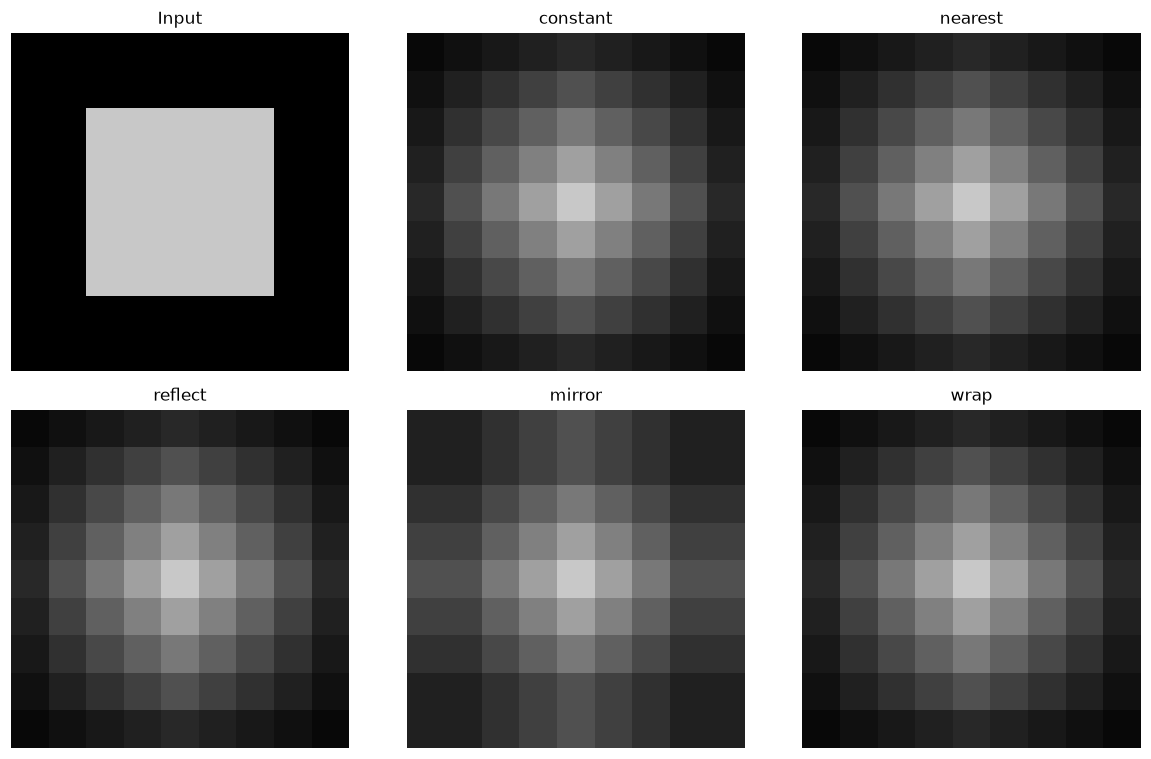

In [91]:

demo = np.zeros((9, 9), dtype=np.float32)
demo[2:7, 2:7] = 200
large_mean_filter_result = np.ones((5, 5), dtype=np.float32) / 25.0
border_modes = {
    "constant": ndimage.convolve(demo, large_mean_filter_result, mode="constant", cval=0.0),
    "nearest": ndimage.convolve(demo, large_mean_filter_result, mode="nearest"),
    "reflect": ndimage.convolve(demo, large_mean_filter_result, mode="reflect"),
    "mirror": ndimage.convolve(demo, large_mean_filter_result, mode="mirror"),
    "wrap": ndimage.convolve(demo, large_mean_filter_result, mode="wrap"),
}

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes = axes.ravel()

axes[0].imshow(demo, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Input")

for ax, (name, result) in zip(axes[1:], border_modes.items()):
    ax.imshow(result, cmap="gray", vmin=0, vmax=255)
    ax.set_title(name)

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_border_modes.png", bbox_inches="tight")
plt.show()

## 7. Mean / Box Filtering


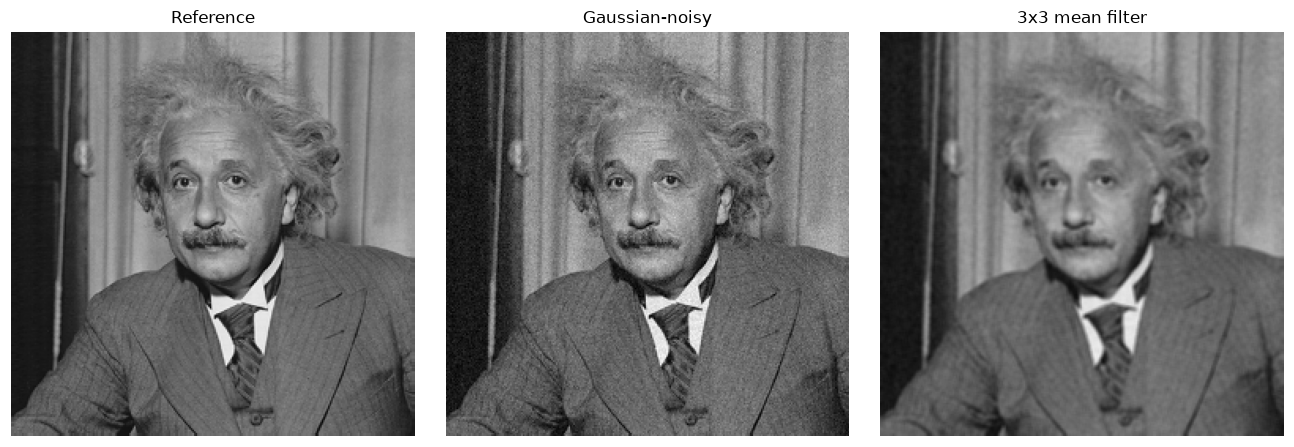

In [92]:

mean_kernel = np.ones((3, 3), dtype=np.float32) / 9.0

mean_filtered_image = ndimage.convolve(
    einstein_gaussian_noise_image.astype(np.float32),
    mean_kernel,
    mode="reflect",
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(einstein_reference_image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Reference")

axes[1].imshow(einstein_gaussian_noise_image, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Gaussian-noisy")

axes[2].imshow(mean_filtered_image, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("3x3 mean filter")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_mean_filter.png", bbox_inches="tight")
plt.show()

### Kernel-Size Sweep


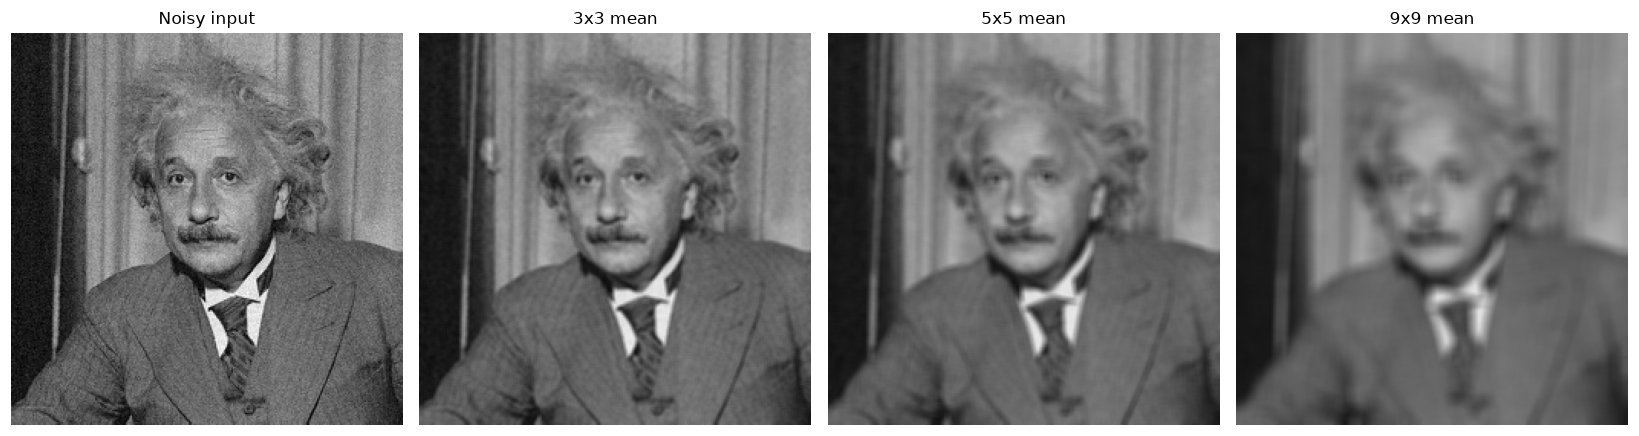

In [93]:

mean_sizes = [3, 5, 9]

mean_filter_results = {}

for size in mean_sizes:
    kernel = np.ones((size, size), dtype=np.float32) / (size * size)
    mean_filter_results[size] = ndimage.convolve(
        einstein_gaussian_noise_image.astype(np.float32),
        kernel,
        mode="reflect",
    )

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].imshow(einstein_gaussian_noise_image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Noisy input")

for ax, size in zip(axes[1:], mean_sizes):
    ax.imshow(mean_filter_results[size], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{size}x{size} mean")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_mean_kernel_sizes.png", bbox_inches="tight")
plt.show()

## 8. Gaussian Filtering


### Gaussian-Kernel Construction


In [94]:

def build_gaussian_kernel_2d(size: int, sigma: float) -> np.ndarray:
    """Build gaussian kernel 2d."""
    assert size % 2 == 1, "Kernel size must be odd."
    assert sigma > 0, "sigma must be positive."
    radius = size // 2
    coords = np.arange(-radius, radius + 1, dtype=np.float64)
    x, y = np.meshgrid(coords, coords)

    kernel = np.exp(-(x**2 + y**2) / (2.0 * sigma**2))
    kernel /= kernel.sum()
    return kernel

gaussian_kernel_2d = build_gaussian_kernel_2d(5, 1.0)

print(np.round(gaussian_kernel_2d, 4))
print("Kernel sum:", gaussian_kernel_2d.sum())

[[0.003  0.0133 0.0219 0.0133 0.003 ]
 [0.0133 0.0596 0.0983 0.0596 0.0133]
 [0.0219 0.0983 0.1621 0.0983 0.0219]
 [0.0133 0.0596 0.0983 0.0596 0.0133]
 [0.003  0.0133 0.0219 0.0133 0.003 ]]
Kernel sum: 1.0


In [95]:

def build_gaussian_kernel_1d(size: int, sigma: float) -> np.ndarray:
    """Build gaussian kernel 1d."""

    radius = size // 2
    x = np.arange(-radius, radius + 1, dtype=np.float64)
    gaussian_weights = np.exp(-(x**2) / (2.0 * sigma**2))
    return gaussian_weights / gaussian_weights.sum()

gaussian_kernel_1d = build_gaussian_kernel_1d(5, 1.0)
outer = np.outer(gaussian_kernel_1d, gaussian_kernel_1d)

print("Maximum difference between 2-D kernel and outer product:")
print(np.max(np.abs(gaussian_kernel_2d - outer)))

assert np.allclose(gaussian_kernel_2d, outer)

Maximum difference between 2-D kernel and outer product:
2.7755575615628914e-17


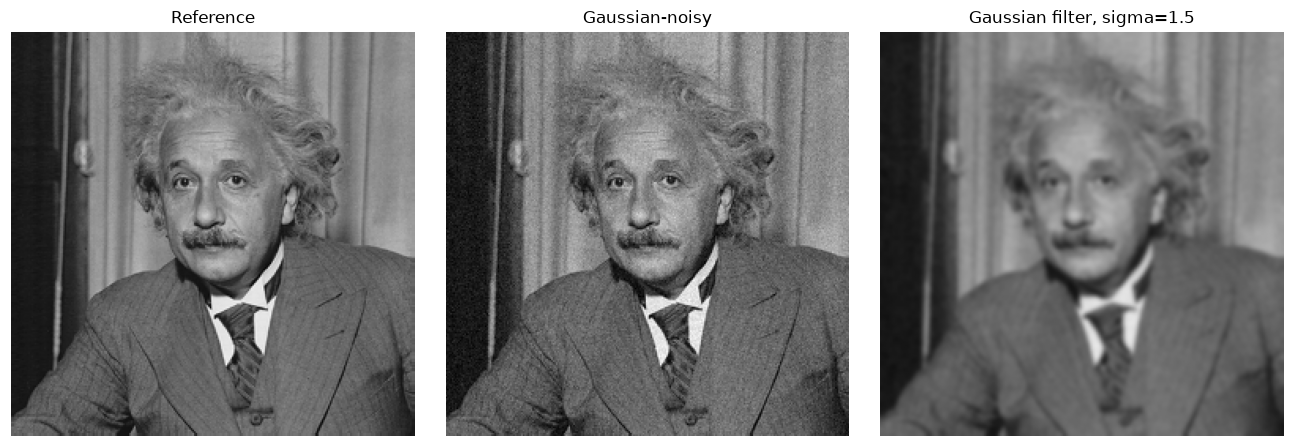

In [96]:

gaussian_filtered_image = ndimage.gaussian_filter(
    einstein_gaussian_noise_image.astype(np.float32),

sigma=1.5,
    mode="reflect",
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(einstein_reference_image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Reference")

axes[1].imshow(einstein_gaussian_noise_image, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Gaussian-noisy")

axes[2].imshow(gaussian_filtered_image, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Gaussian filter, sigma=1.5")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_gaussian_filter.png", bbox_inches="tight")
plt.show()

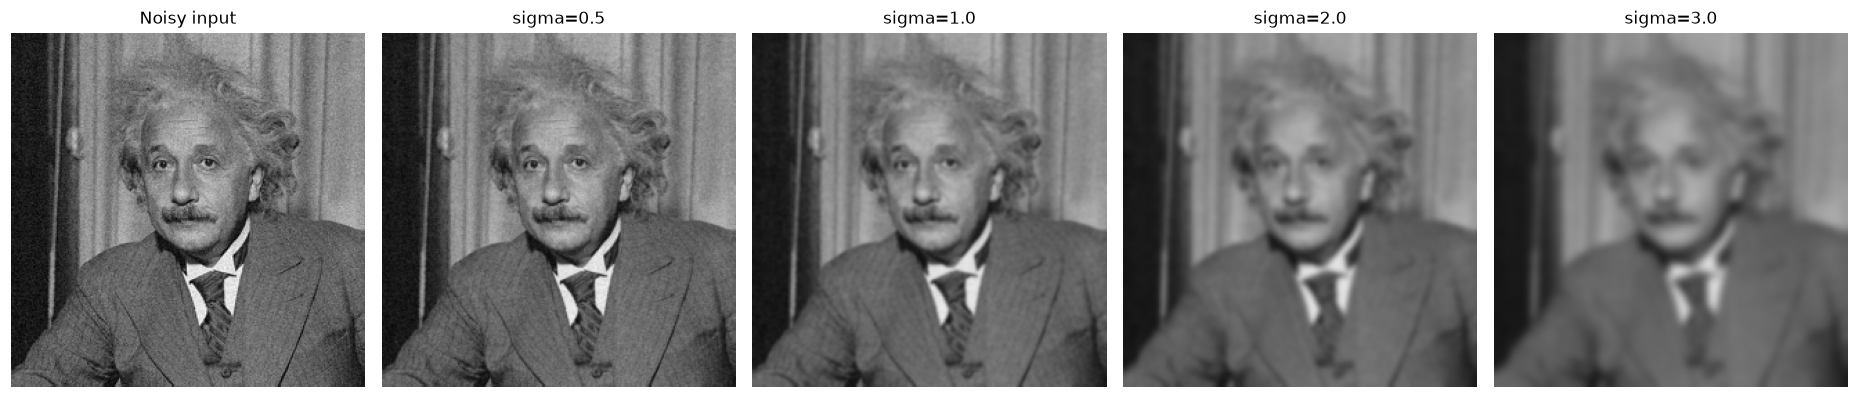

In [97]:

sigmas = [0.5, 1.0, 2.0, 3.0]

gaussian_filter_results = {
    sigma: ndimage.gaussian_filter(
        einstein_gaussian_noise_image.astype(np.float32),
        sigma=sigma,
        mode="reflect",
    )
    for sigma in sigmas
}

fig, axes = plt.subplots(1, 5, figsize=(17, 4))

axes[0].imshow(einstein_gaussian_noise_image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Noisy input")

for ax, sigma in zip(axes[1:], sigmas):
    ax.imshow(gaussian_filter_results[sigma], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"sigma={sigma}")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_gaussian_sigma_sweep.png", bbox_inches="tight")
plt.show()

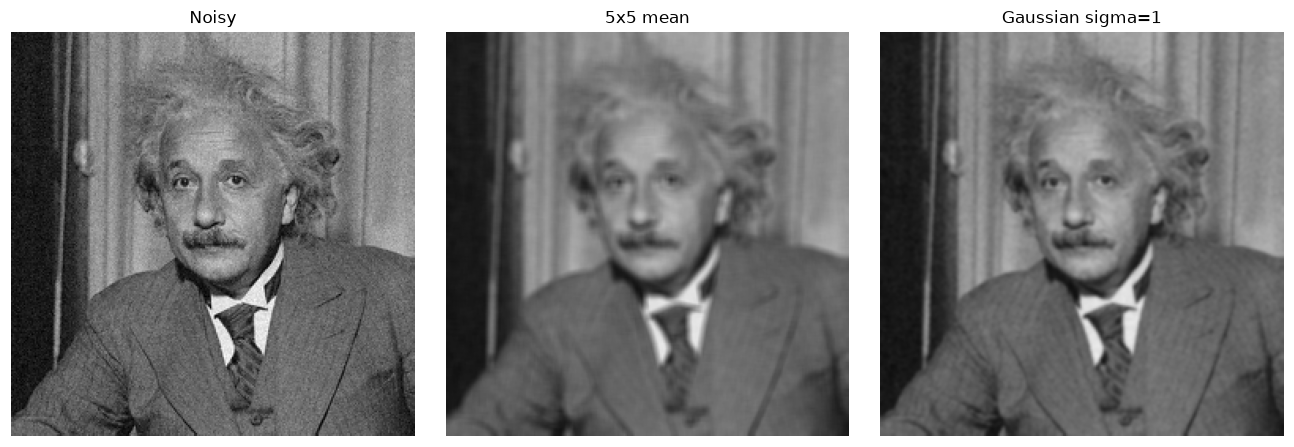

In [98]:

mean_5 = ndimage.uniform_filter(
    einstein_gaussian_noise_image.astype(np.float32),
    size=5,
    mode="reflect",
)
gauss_approx = ndimage.gaussian_filter(
    einstein_gaussian_noise_image.astype(np.float32),
    sigma=1.0,
    mode="reflect",
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(
    axes,
    [einstein_gaussian_noise_image, mean_5, gauss_approx],
    ["Noisy", "5x5 mean", "Gaussian sigma=1"],
):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_mean_vs_gaussian.png", bbox_inches="tight")
plt.show()

## 9. Noise-Model Dependence


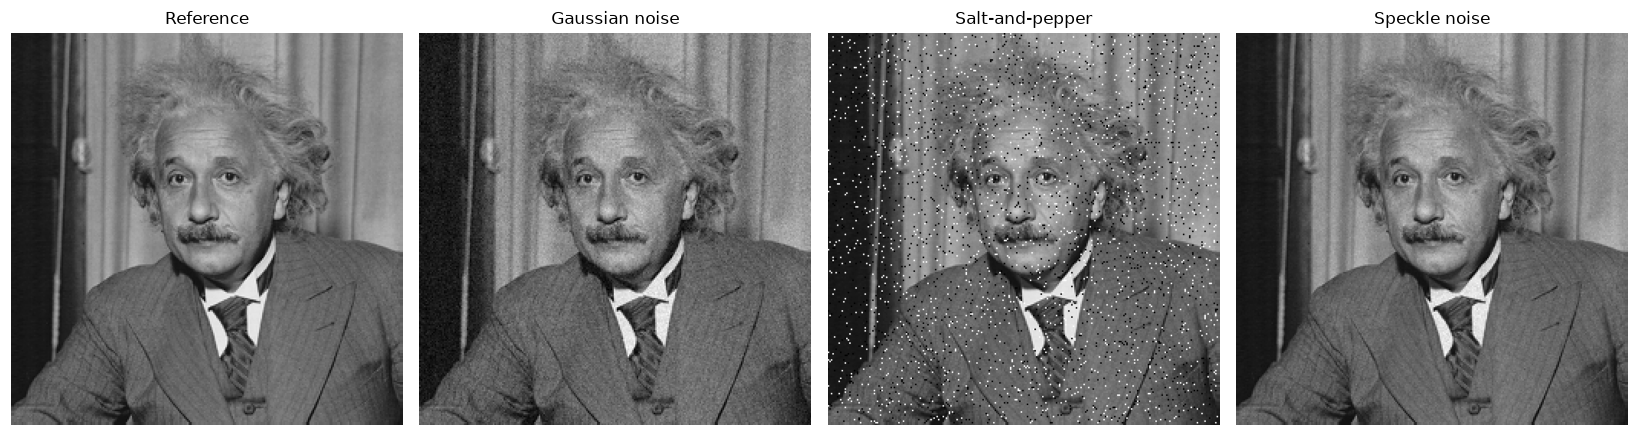

In [99]:

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, img, title in zip(
    axes,

[einstein_reference_image, einstein_gaussian_noise_image, einstein_salt_pepper_noise_image, einstein_speckle_noise_image],
    ["Reference", "Gaussian noise", "Salt-and-pepper", "Speckle noise"],
):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_noise_types.png", bbox_inches="tight")
plt.show()

## 10. Median Filtering


In [100]:

values = np.array([20, 21, 20, 22, 255, 19, 20, 21, 20])

print("Values:", values)
print("Sorted:", np.sort(values))
print("Mean  :", values.mean())
print("Median:", np.median(values))

Values: [ 20  21  20  22 255  19  20  21  20]
Sorted: [ 19  20  20  20  20  21  21  22 255]
Mean  : 46.44444444444444
Median: 20.0


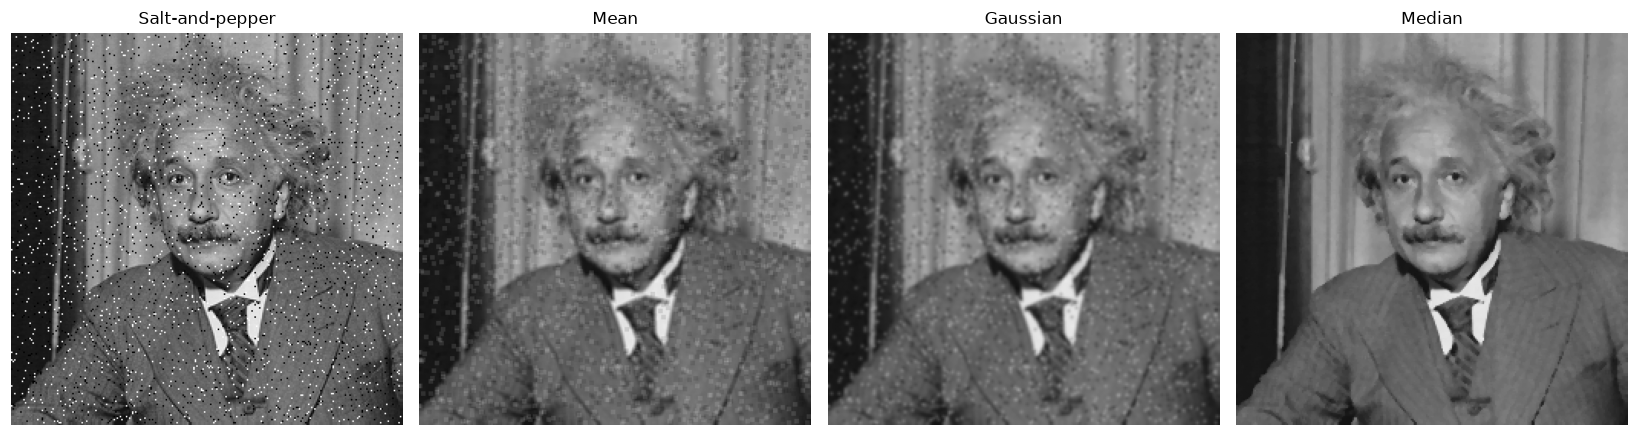

In [101]:

median_filtered = ndimage.median_filter(
    einstein_salt_pepper_noise_image,
    size=3,
    mode="reflect",
)
mean_on_salt = ndimage.uniform_filter(
    einstein_salt_pepper_noise_image.astype(np.float32),
    size=3,
    mode="reflect",
)

gaussian_on_salt = ndimage.gaussian_filter(
    einstein_salt_pepper_noise_image.astype(np.float32),
    sigma=1.0,
    mode="reflect",
)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, img, title in zip(
    axes,
    [einstein_salt_pepper_noise_image, mean_on_salt, gaussian_on_salt, median_filtered],
    ["Salt-and-pepper", "Mean", "Gaussian", "Median"],
):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "08_median_filter.png", bbox_inches="tight")
plt.show()

### Median-Window Sweep


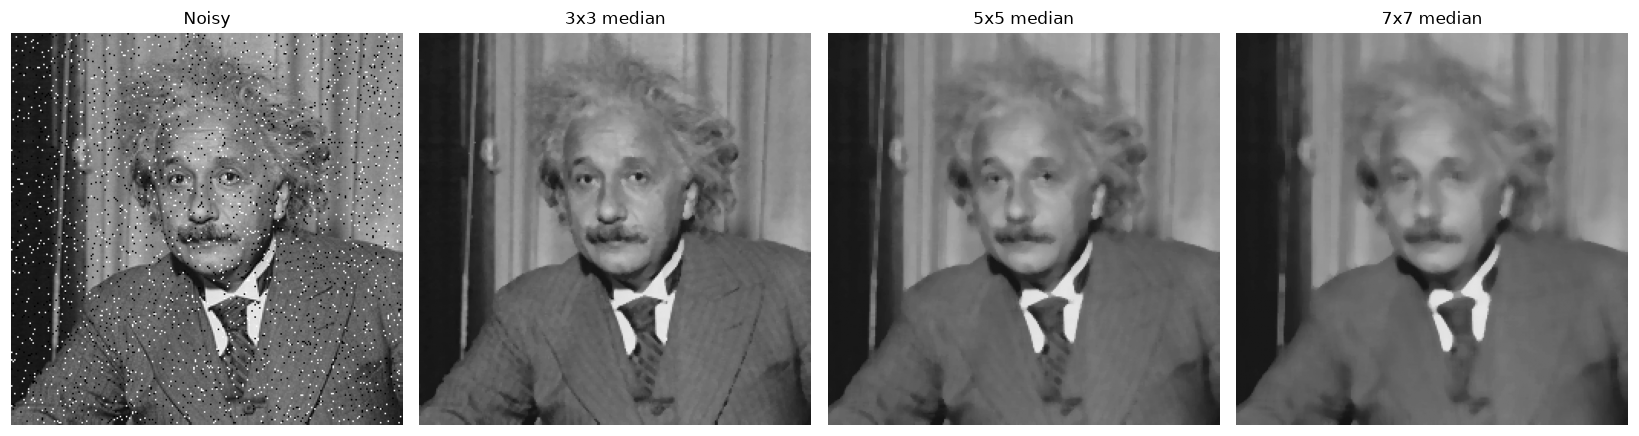

In [102]:

median_sizes = [3, 5, 7]

median_results = {
    size: ndimage.median_filter(einstein_salt_pepper_noise_image, size=size, mode="reflect")
    for size in median_sizes
}

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].imshow(einstein_salt_pepper_noise_image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Noisy")

for ax, size in zip(axes[1:], median_sizes):
    ax.imshow(median_results[size], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{size}x{size} median")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "09_median_sizes.png", bbox_inches="tight")
plt.show()

## 11. Bilateral Filtering


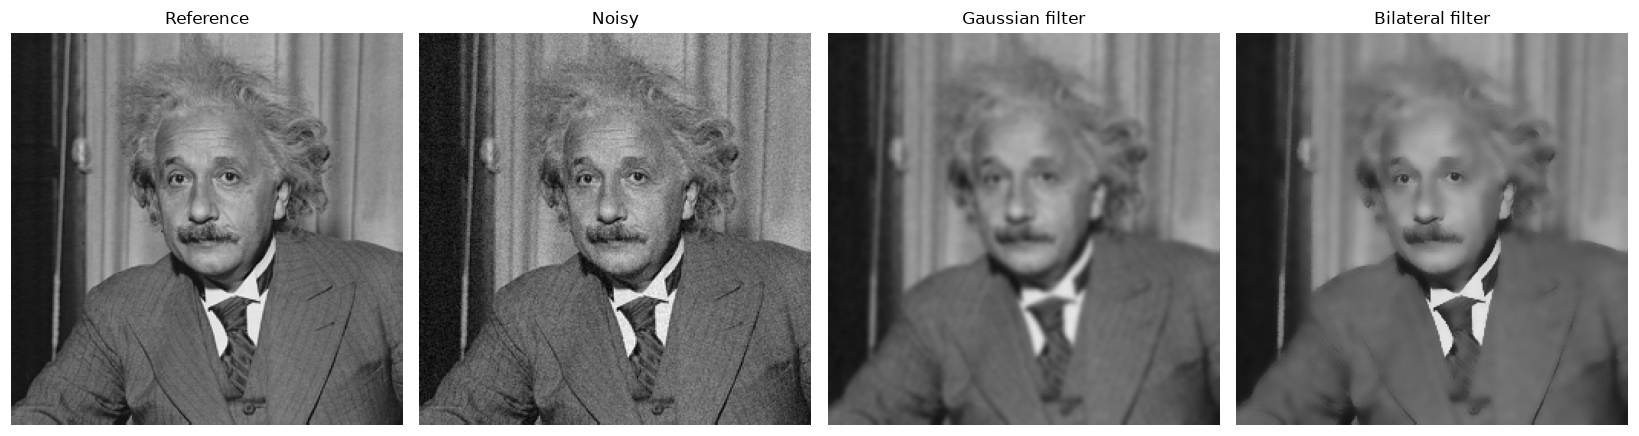

In [103]:

# Bilateral filtering is retained because it can suppress noise without smoothing strong edges as aggressively.
einstein_bilateral_filtered_image = cv2.bilateralFilter(
    einstein_gaussian_noise_image,

d=9,

    sigmaColor=45,
    sigmaSpace=45,
)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, img, title in zip(
    axes,
    [einstein_reference_image, einstein_gaussian_noise_image, gaussian_filtered_image, einstein_bilateral_filtered_image],
    ["Reference", "Noisy", "Gaussian filter", "Bilateral filter"],
):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "10_bilateral_filter.png", bbox_inches="tight")
plt.show()

### Bilateral-Parameter Sweep


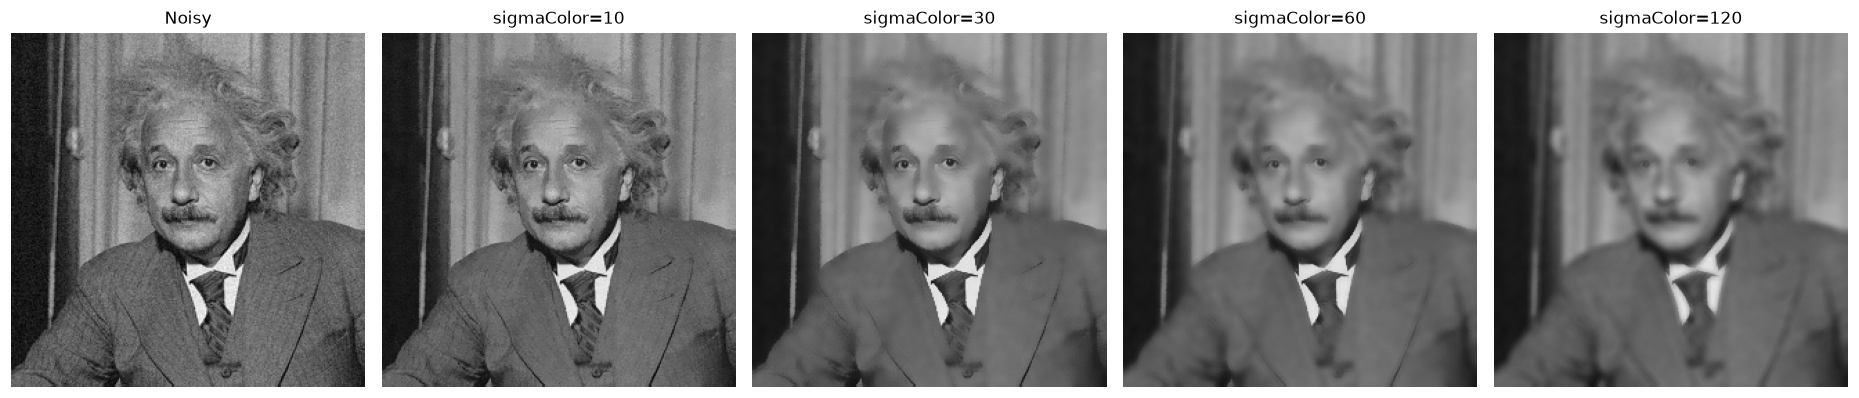

In [104]:

sigma_colors = [10, 30, 60, 120]
bilateral_results = {
    sc: cv2.bilateralFilter(
        einstein_gaussian_noise_image,
        d=9,
        sigmaColor=sc,
        sigmaSpace=45,
    )
    for sc in sigma_colors
}

fig, axes = plt.subplots(1, 5, figsize=(17, 4))

axes[0].imshow(einstein_gaussian_noise_image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Noisy")

for ax, sc in zip(axes[1:], sigma_colors):
    ax.imshow(bilateral_results[sc], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"sigmaColor={sc}")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "11_bilateral_parameter_sweep.png", bbox_inches="tight")
plt.show()

## 12. Quantitative Denoising Metrics


In [105]:

def mean_absolute_error(reference, test):
    """Mean absolute error."""
    ref = reference.astype(np.float64)
    tst = np.asarray(test, dtype=np.float64)
    return float(np.mean(np.abs(ref - tst)))

def mean_squared_error(reference, test):
    """Mean squared error."""
    ref = reference.astype(np.float64)
    tst = np.asarray(test, dtype=np.float64)
    return float(np.mean((ref - tst) ** 2))

def root_mean_squared_error(reference, test):
    """Root mean squared error."""
    return math.sqrt(mean_squared_error(reference, test))

def peak_signal_to_noise_ratio(reference, test, peak=255.0):
    """Peak signal to noise ratio."""
    value = mean_squared_error(reference, test)

    if value == 0:
        return float("inf")
    return 10.0 * math.log10((peak ** 2) / value)

def build_metric_summary(name, reference, test):
    """Build metric summary."""
    return (
        name,
        mean_absolute_error(reference, test),
        mean_squared_error(reference, test),
        root_mean_squared_error(reference, test),
        peak_signal_to_noise_ratio(reference, test),
    )

### Gaussian-Noise Comparison


In [106]:

gaussian_candidates = [
    build_metric_summary("Noisy", einstein_reference_image, einstein_gaussian_noise_image),
    build_metric_summary("Mean 3x3", einstein_reference_image, mean_filtered_image),
    build_metric_summary("Gaussian sigma=1.5", einstein_reference_image, gaussian_filtered_image),
    build_metric_summary("Bilateral", einstein_reference_image, einstein_bilateral_filtered_image),
]

print(f"{'Method':24s} {'MAE':>10s} {'MSE':>12s} {'RMSE':>10s} {'PSNR(dB)':>10s}")
print("-" * 72)

for name, a, m, r, p in gaussian_candidates:
    print(f"{name:24s} {a:10.3f} {m:12.3f} {r:10.3f} {p:10.3f}")

Method                          MAE          MSE       RMSE   PSNR(dB)
------------------------------------------------------------------------
Noisy                         6.422       65.074      8.067     29.997
Mean 3x3                      5.684       72.083      8.490     29.552
Gaussian sigma=1.5            6.879      117.394     10.835     27.434
Bilateral                     6.271       74.966      8.658     29.382


### Impulse-Noise Comparison


In [107]:

salt_candidates = [
    build_metric_summary("Noisy", einstein_reference_image, einstein_salt_pepper_noise_image),
    build_metric_summary("Mean 3x3", einstein_reference_image, mean_on_salt),
    build_metric_summary("Gaussian sigma=1", einstein_reference_image, gaussian_on_salt),
    build_metric_summary("Median 3x3", einstein_reference_image, median_filtered),
]

print(f"{'Method':24s} {'MAE':>10s} {'MSE':>12s} {'RMSE':>10s} {'PSNR(dB)':>10s}")
print("-" * 72)

for name, a, m, r, p in salt_candidates:
    print(f"{name:24s} {a:10.3f} {m:12.3f} {r:10.3f} {p:10.3f}")

Method                          MAE          MSE       RMSE   PSNR(dB)
------------------------------------------------------------------------
Noisy                         6.411      906.353     30.106     18.558
Mean 3x3                      8.987      171.381     13.091     25.791
Gaussian sigma=1              8.229      146.080     12.086     26.485
Median 3x3                    4.074       50.307      7.093     31.115


## 13. Edge Preservation as a Secondary Check


In [108]:

def compute_sobel_gradient_magnitude(image):
    """Compute sobel gradient magnitude."""
    image_array = np.asarray(image, dtype=np.float32)
    # Reflect padding avoids artificial border edges while preserving local image continuity.
    gx = ndimage.sobel(image_array, axis=1, mode="reflect")
    gy = ndimage.sobel(image_array, axis=0, mode="reflect")
    return np.hypot(gx, gy)

edge_ref = compute_sobel_gradient_magnitude(einstein_reference_image)

edge_mean = compute_sobel_gradient_magnitude(mean_filtered_image)
edge_gauss = compute_sobel_gradient_magnitude(gaussian_filtered_image)
edge_bilat = compute_sobel_gradient_magnitude(einstein_bilateral_filtered_image)

print("Mean gradient magnitude")
print(f"Reference : {edge_ref.mean():.3f}")
print(f"Mean      : {edge_mean.mean():.3f}")
print(f"Gaussian  : {edge_gauss.mean():.3f}")
print(f"Bilateral : {edge_bilat.mean():.3f}")

Mean gradient magnitude
Reference : 60.720
Mean      : 46.611
Gaussian  : 33.077
Bilateral : 31.769


## 14. Sharpening with the Laplacian


In [109]:

laplacian_kernel = np.array(
    [
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0],
    ],
    dtype=np.float32,
)

print(laplacian_kernel)
print("Kernel sum:", laplacian_kernel.sum())

[[ 0.  1.  0.]
 [ 1. -4.  1.]
 [ 0.  1.  0.]]
Kernel sum: 0.0


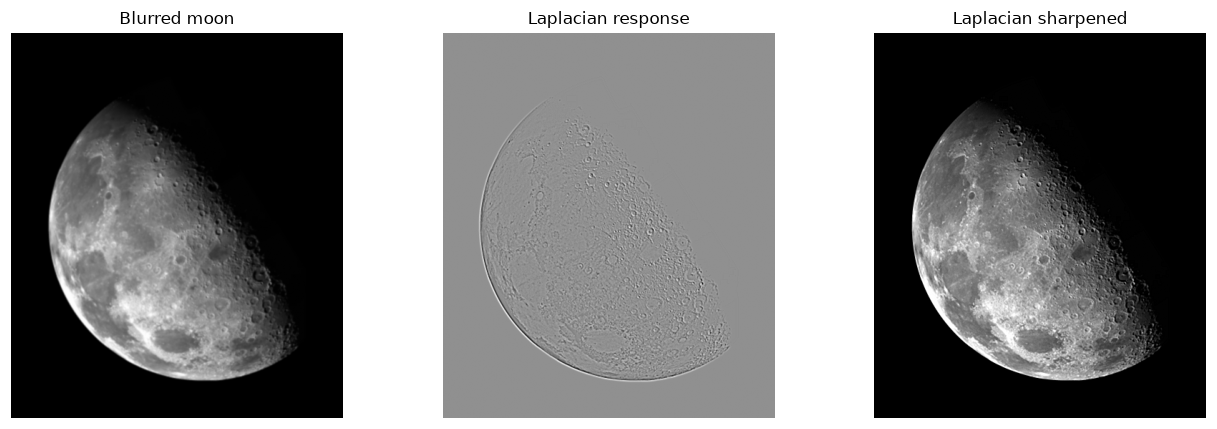

In [110]:

moon_float = moon.astype(np.float32)
laplacian = ndimage.convolve(
    moon_float,
    laplacian_kernel,
    mode="reflect",
)

lap_sharp = np.clip(
    moon_float - laplacian,
    0,
    255,
).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(moon, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Blurred moon")

axes[1].imshow(laplacian, cmap="gray")
axes[1].set_title("Laplacian response")

axes[2].imshow(lap_sharp, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Laplacian sharpened")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "12_laplacian_sharpening.png", bbox_inches="tight")
plt.show()

## 15. Unsharp Masking and High-Boost Filtering


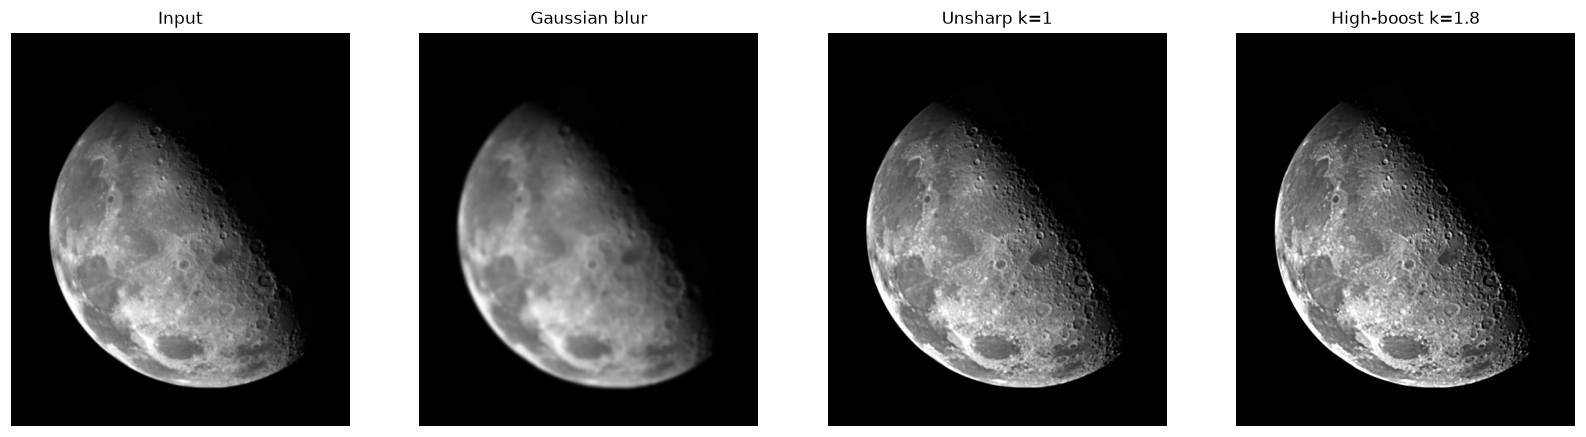

In [111]:

blurred = ndimage.gaussian_filter(moon_float, sigma=2.0, mode="reflect")
detail_mask = moon_float - blurred

unsharp = np.clip(
    moon_float + 1.0 * detail_mask,
    0,
    255,
).astype(np.uint8)

high_boost = np.clip(
    moon_float + 1.8 * detail_mask,
    0,
    255,
).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, img, title in zip(
    axes,
    [moon, blurred, unsharp, high_boost],
    ["Input", "Gaussian blur", "Unsharp k=1", "High-boost k=1.8"],
):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "13_unsharp_highboost.png", bbox_inches="tight")
plt.show()

## 16. First Derivatives and Image Gradients


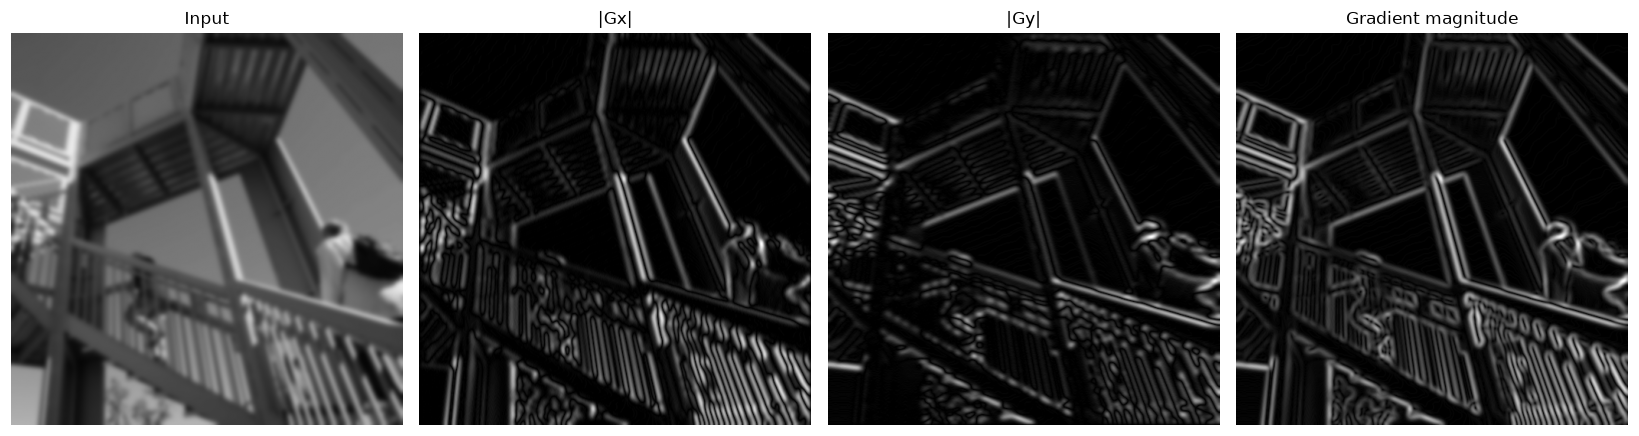

In [112]:

gx = ndimage.sobel(ascent.astype(np.float32), axis=1, mode="reflect")
gy = ndimage.sobel(ascent.astype(np.float32), axis=0, mode="reflect")
magnitude = np.hypot(gx, gy)
orientation = np.arctan2(gy, gx)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].imshow(ascent, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Input")

axes[1].imshow(np.abs(gx), cmap="gray")
axes[1].set_title("|Gx|")

axes[2].imshow(np.abs(gy), cmap="gray")
axes[2].set_title("|Gy|")

axes[3].imshow(magnitude, cmap="gray")
axes[3].set_title("Gradient magnitude")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "14_sobel_gradients.png", bbox_inches="tight")
plt.show()

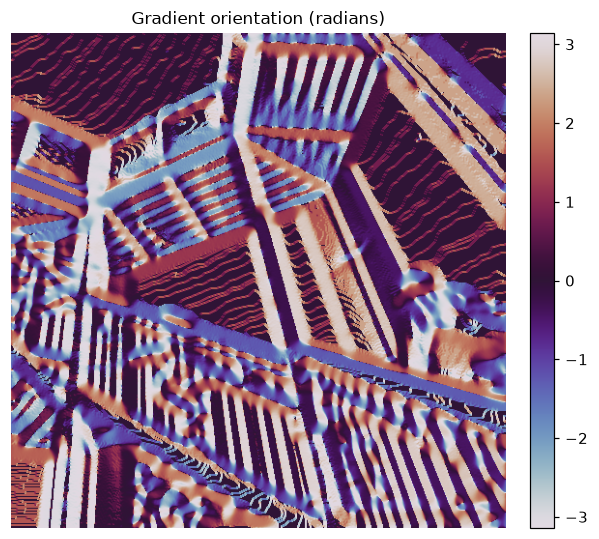

In [113]:

fig, ax = plt.subplots(figsize=(6, 5))
orientation_display = ax.imshow(orientation, cmap="twilight", vmin=-np.pi, vmax=np.pi)
ax.set_title("Gradient orientation (radians)")
ax.axis("off")
fig.colorbar(orientation_display, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "15_gradient_orientation.png", bbox_inches="tight")
plt.show()

## 17. Sobel vs Prewitt vs Scharr


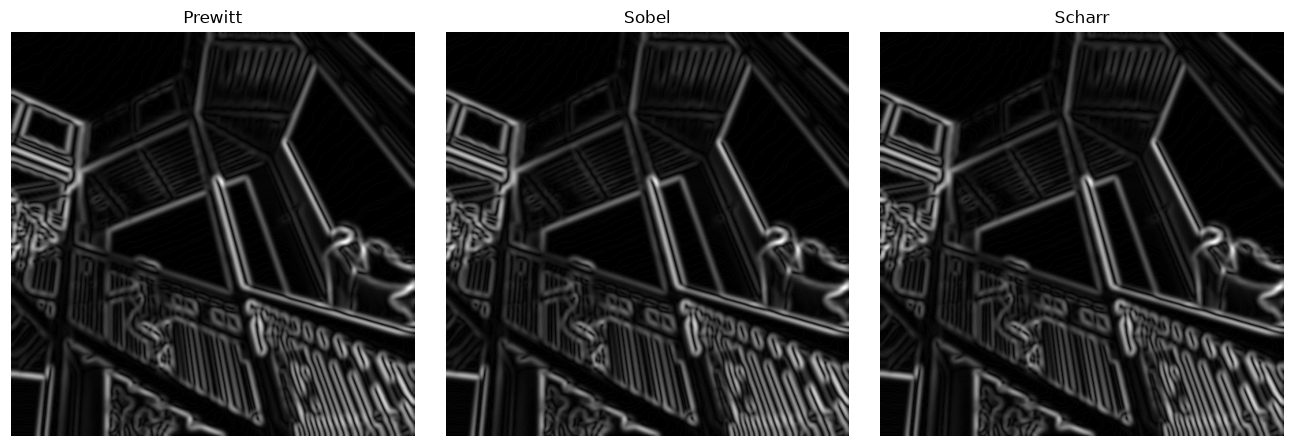

In [114]:

ascent_float_image = ascent.astype(np.float32)
prewitt_x = ndimage.prewitt(ascent_float_image, axis=1, mode="reflect")
prewitt_y = ndimage.prewitt(ascent_float_image, axis=0, mode="reflect")
prewitt_mag = np.hypot(prewitt_x, prewitt_y)

sobel_x = ndimage.sobel(ascent_float_image, axis=1, mode="reflect")
sobel_y = ndimage.sobel(ascent_float_image, axis=0, mode="reflect")
sobel_mag = np.hypot(sobel_x, sobel_y)

scharr_x = cv2.Scharr(ascent_float_image, cv2.CV_32F, 1, 0)
scharr_y = cv2.Scharr(ascent_float_image, cv2.CV_32F, 0, 1)
scharr_mag = np.hypot(scharr_x, scharr_y)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, img, title in zip(
    axes,
    [prewitt_mag, sobel_mag, scharr_mag],
    ["Prewitt", "Sobel", "Scharr"],
):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "16_derivative_operators.png", bbox_inches="tight")
plt.show()

## 18. Border Effects on a Real Image


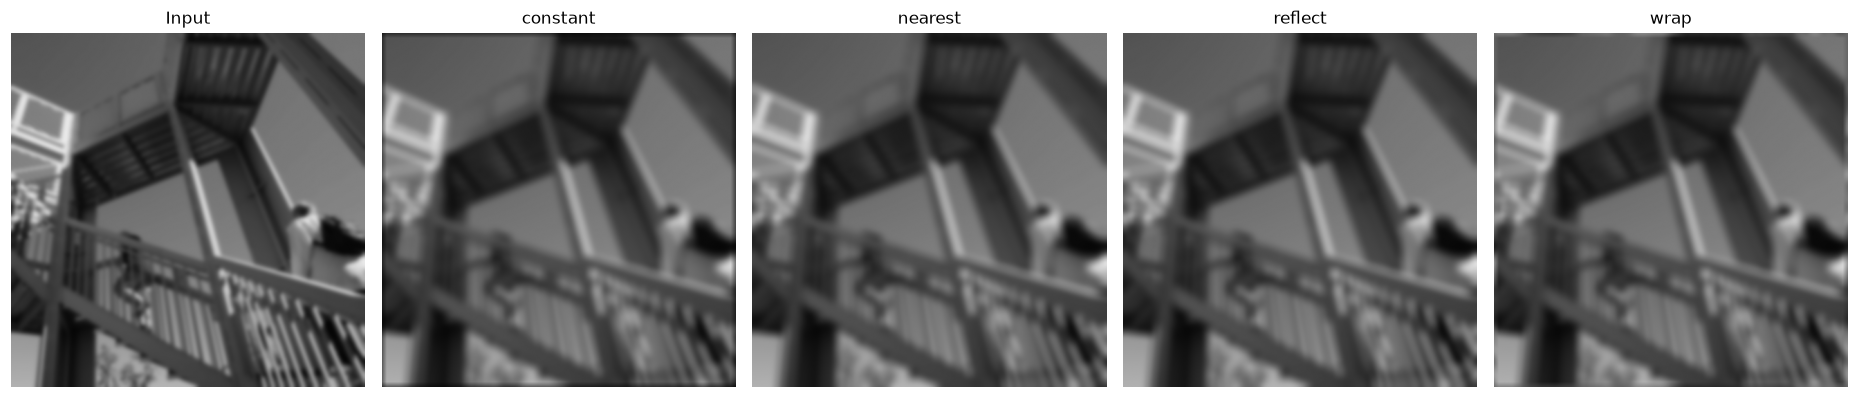

In [115]:

kernel_15 = np.ones((15, 15), dtype=np.float32) / (15 * 15)
ascent_float_image = ascent.astype(np.float32)
padding_results = {
    "constant": ndimage.convolve(ascent_float_image, kernel_15, mode="constant", cval=0.0),
    "nearest": ndimage.convolve(ascent_float_image, kernel_15, mode="nearest"),
    "reflect": ndimage.convolve(ascent_float_image, kernel_15, mode="reflect"),
    "wrap": ndimage.convolve(ascent_float_image, kernel_15, mode="wrap"),
}

fig, axes = plt.subplots(1, 5, figsize=(17, 4))

axes[0].imshow(ascent, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Input")

for ax, (name, img) in zip(axes[1:], padding_results.items()):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(name)

for ax in axes:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "17_padding_real_image.png", bbox_inches="tight")
plt.show()

## 19. Filtering RGB Images


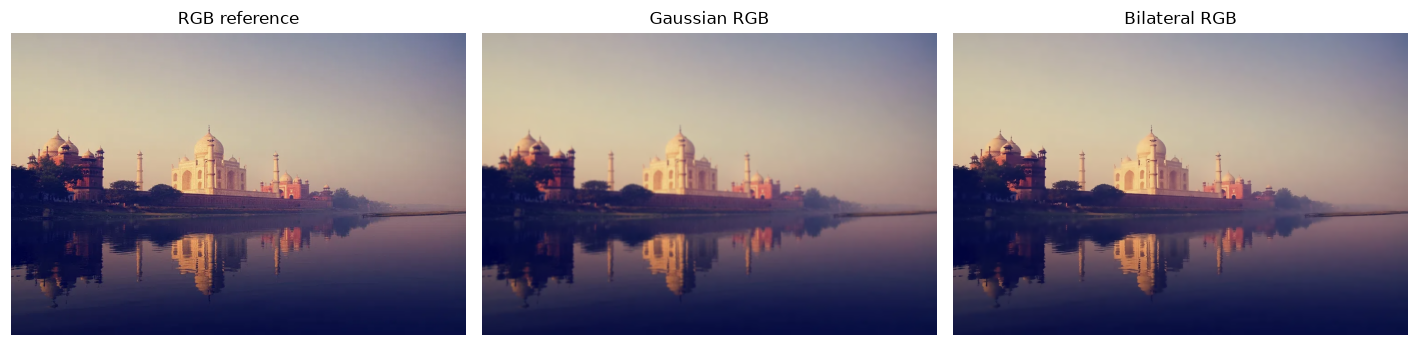

In [116]:

taj_gaussian = ndimage.gaussian_filter(
    taj_reference_image.astype(np.float32),

sigma=(1.5, 1.5, 0),
    mode="reflect",
)
taj_bilateral = cv2.bilateralFilter(
    taj_reference_image,
    d=9,
    sigmaColor=45,
    sigmaSpace=45,
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, img, title in zip(
    axes,
    [taj_reference_image, np.clip(taj_gaussian, 0, 255).astype(np.uint8), taj_bilateral],
    ["RGB reference", "Gaussian RGB", "Bilateral RGB"],
):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "18_color_filtering.png", bbox_inches="tight")
plt.show()

## 20. Numerical Safety


In [117]:

example_uint8 = np.array([0, 10, 250, 255], dtype=np.uint8)
unsafe = example_uint8 + np.uint8(20)
safe = example_uint8.astype(np.float32) + 20

print("Original:", example_uint8)
print("Unsafe uint8 + 20:", unsafe)
print("Safe float + 20 :", safe)
print("Clipped result  :", np.clip(safe, 0, 255).astype(np.uint8))

Original: [  0  10 250 255]
Unsafe uint8 + 20: [20 30 14 19]
Safe float + 20 : [ 20.  30. 270. 275.]
Clipped result  : [ 20  30 255 255]


## 21. Filter Selection Criteria

In [118]:

best_gaussian_noise_method = min(
    gaussian_candidates[1:],
    key=lambda row: row[2],
)

best_impulse_noise_method = min(
    salt_candidates[1:],
    key=lambda row: row[2],
)
edge_retention = {
    "Mean 3x3": float(edge_mean.mean() / max(edge_ref.mean(), 1e-12)),
    "Gaussian sigma=1.5": float(edge_gauss.mean() / max(edge_ref.mean(), 1e-12)),
    "Bilateral": float(edge_bilat.mean() / max(edge_ref.mean(), 1e-12)),
}

print("Best Gaussian-noise restoration by MSE:")
print(
    f"  {best_gaussian_noise_method[0]} "
    f"(MSE={best_gaussian_noise_method[2]:.3f}, "
    f"PSNR={best_gaussian_noise_method[4]:.3f} dB)"
)

print("\nBest impulse-noise restoration by MSE:")
print(
    f"  {best_impulse_noise_method[0]} "
    f"(MSE={best_impulse_noise_method[2]:.3f}, "
    f"PSNR={best_impulse_noise_method[4]:.3f} dB)"
)

print("\nRelative mean-gradient retention:")
for method, ratio in edge_retention.items():
    print(f"  {method:20s}: {ratio:.3f}")

Best Gaussian-noise restoration by MSE:
  Mean 3x3 (MSE=72.083, PSNR=29.552 dB)

Best impulse-noise restoration by MSE:
  Median 3x3 (MSE=50.307, PSNR=31.115 dB)

Relative mean-gradient retention:
  Mean 3x3            : 0.768
  Gaussian sigma=1.5  : 0.545
  Bilateral           : 0.523


## 22. Standard Spatial-Filtering Workflow

In [119]:

def apply_spatial_filter(
    image,
    method="gaussian",
    kernel_size=5,
    sigma=1.5,
):
    """Apply spatial filter."""
    image = np.asarray(image, dtype=np.float32)
    if image.ndim != 2:
        raise ValueError("apply_spatial_filter expects a 2-D grayscale image.")
    if kernel_size <= 0 or kernel_size % 2 == 0:
        raise ValueError("kernel_size must be a positive odd integer.")

    if method == "mean":
        return ndimage.uniform_filter(
            image,
            size=kernel_size,
            mode="reflect",
        )

    if method == "gaussian":
        if sigma <= 0:
            raise ValueError("sigma must be strictly positive.")
        return ndimage.gaussian_filter(
            image,
            sigma=sigma,
            mode="reflect",
        )

    if method == "median":
        return ndimage.median_filter(
            image,
            size=kernel_size,
            mode="reflect",
        )

    raise ValueError(
        "method must be one of: 'mean', 'gaussian', 'median'."
    )
workflow_result = apply_spatial_filter(
    einstein_gaussian_noise_image,
    method="gaussian",
    kernel_size=5,
    sigma=1.5,
)

assert workflow_result.shape == einstein_gaussian_noise_image.shape
assert np.all(np.isfinite(workflow_result))

print(
    "Workflow example:",
    "Gaussian sigma=1.5",
    f"shape={workflow_result.shape}",
    f"MSE={mean_squared_error(einstein_reference_image, workflow_result):.3f}",
)

Workflow example: Gaussian sigma=1.5 shape=(256, 256) MSE=117.394


## 23. Validation Checks


In [120]:

assert mean_filtered_image.shape == einstein_reference_image.shape
assert gaussian_filtered_image.shape == einstein_reference_image.shape
assert median_filtered.shape == einstein_reference_image.shape
assert einstein_bilateral_filtered_image.shape == einstein_reference_image.shape
assert np.isclose(mean_kernel.sum(), 1.0)

assert np.isclose(gaussian_kernel_2d.sum(), 1.0)
assert np.isclose(sobel_x_kernel.sum(), 0.0)
assert np.isclose(laplacian_kernel.sum(), 0.0)
assert np.allclose(manual_convolution_result, scipy_convolution_result)

assert np.all(magnitude >= 0)

assert taj_gaussian.shape == taj_reference_image.shape
assert taj_bilateral.shape == taj_reference_image.shape

assert lap_sharp.min() >= 0 and lap_sharp.max() <= 255
assert unsharp.min() >= 0 and unsharp.max() <= 255

print("All spatial-filtering validation checks passed.")
REQUIRED_OUTPUTS = [
    "01_border_modes.png",
    "02_mean_filter.png",
    "03_mean_kernel_sizes.png",
    "04_gaussian_filter.png",
    "05_gaussian_sigma_sweep.png",
    "06_mean_vs_gaussian.png",
    "07_noise_types.png",
    "08_median_filter.png",
    "09_median_sizes.png",
    "10_bilateral_filter.png",
    "11_bilateral_parameter_sweep.png",
    "12_laplacian_sharpening.png",
    "13_unsharp_highboost.png",
    "14_sobel_gradients.png",
    "15_gradient_orientation.png",
    "16_derivative_operators.png",
    "17_padding_real_image.png",
    "18_color_filtering.png",
]
missing_outputs = [
    output_name
    for output_name in REQUIRED_OUTPUTS
    if not (OUTPUT_DIR / output_name).exists()
]
if missing_outputs:
    raise FileNotFoundError(
        "Missing outputs: " + ", ".join(missing_outputs)
    )

print(f"Output validation passed: {len(REQUIRED_OUTPUTS)} files.")


All spatial-filtering validation checks passed.
Output validation passed: 18 files.
